# PLUTO: First Inspection

This page opens a PLUTO snapshot and looks at what is inside it. It is the shortest path
from a file on disk to a picture, and it is the same path you would take with any other
code Mera reads.

The run is a 3-D Sedov blast: a point explosion in a uniform box, 64³ cells.

!!! note "About this run"
    This snapshot was produced locally, so you cannot download this exact one. Everything
    below works the same on your own PLUTO output: change the path and the output number.
    A public PLUTO-AMR snapshot is used on the Chombo page.


## 1. One call to see everything

`quicklook` is the fastest way to find out what an unfamiliar snapshot holds. It reads the
gas, makes projections along all three axes and a phase diagram, and prints a summary.


In [1]:
using Mera, CairoMakie

path = "/Volumes/FASTStorage/Simulations/Mera-Tests/PLUTO/pluto_sedov3d"

# PLUTO stores neither its unit constants nor its gas composition in the output.
# The units come from this run's log; the composition is PLUTO's default, fully ionised.
UL, UD, UV = 1.496e13, 1.673e-24, 1e5   # cm, g/cm^3, cm/s  (1 AU, 1 proton/cm^3, 1 km/s)

ql = quicklook(5; path=path, unit_length=UL, unit_density=UD, unit_velocity=UV,
                  X_frac=0.711, mu=0.614);


[ Info: Precompiling Mera [02f895e8-fdb1-4346-8fe6-c721699f5126](cache misses: include_dependency fsize change (1), wrong dep version loaded (5), mismatched flags (3))


[ Info: Precompiling Mera [02f895e8-fdb1-4346-8fe6-c721699f5126] (cache misses: include_dependency fsize change (2), wrong dep version loaded (10), mismatched flags (6))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v2.0.0-DEV | Julia 1.12.7 | 8 threads



...

[ Info: Mera v2.0.0-DEV


[Mera]: quicklook output 5, reading gas: 2026-09-15T19:33:39.747



   1 CPU file(s), levels 6-6 of 6  (full resolution)
   projecting 3 gas map(s) [z, x, y] and the phase diagram from 262144 cells


┌─ Mera quicklook ── output 5 (PLUTO) ───────────────


│ box        : 4.848e-9 kpc      levels 6–6  (finest 7.575e-8 pc)
│ grid       : ndim 3 · ncpu 1 · nvarh 5
│ time       : 2.37e-6 Myr  (non-cosmological)
│ read       : 262144 cells  (full resolution)
│ gas mass   : 2.816e-18 M⊙
│ nH range   : 0.001293 … 2.895 cm⁻³
│ T  range   : 0.0007382 … 4760.0 K
└─ 6.24 s ──────────────────────────────────
[Mera]: quicklook output 5 finished: 2026-09-15T19:33:43.720



`quicklook` prints the summary and keeps the maps it made. It does not draw them,
so that Mera needs no plotting package to run. Pass the result to `quicklookplot`
when you want the picture:


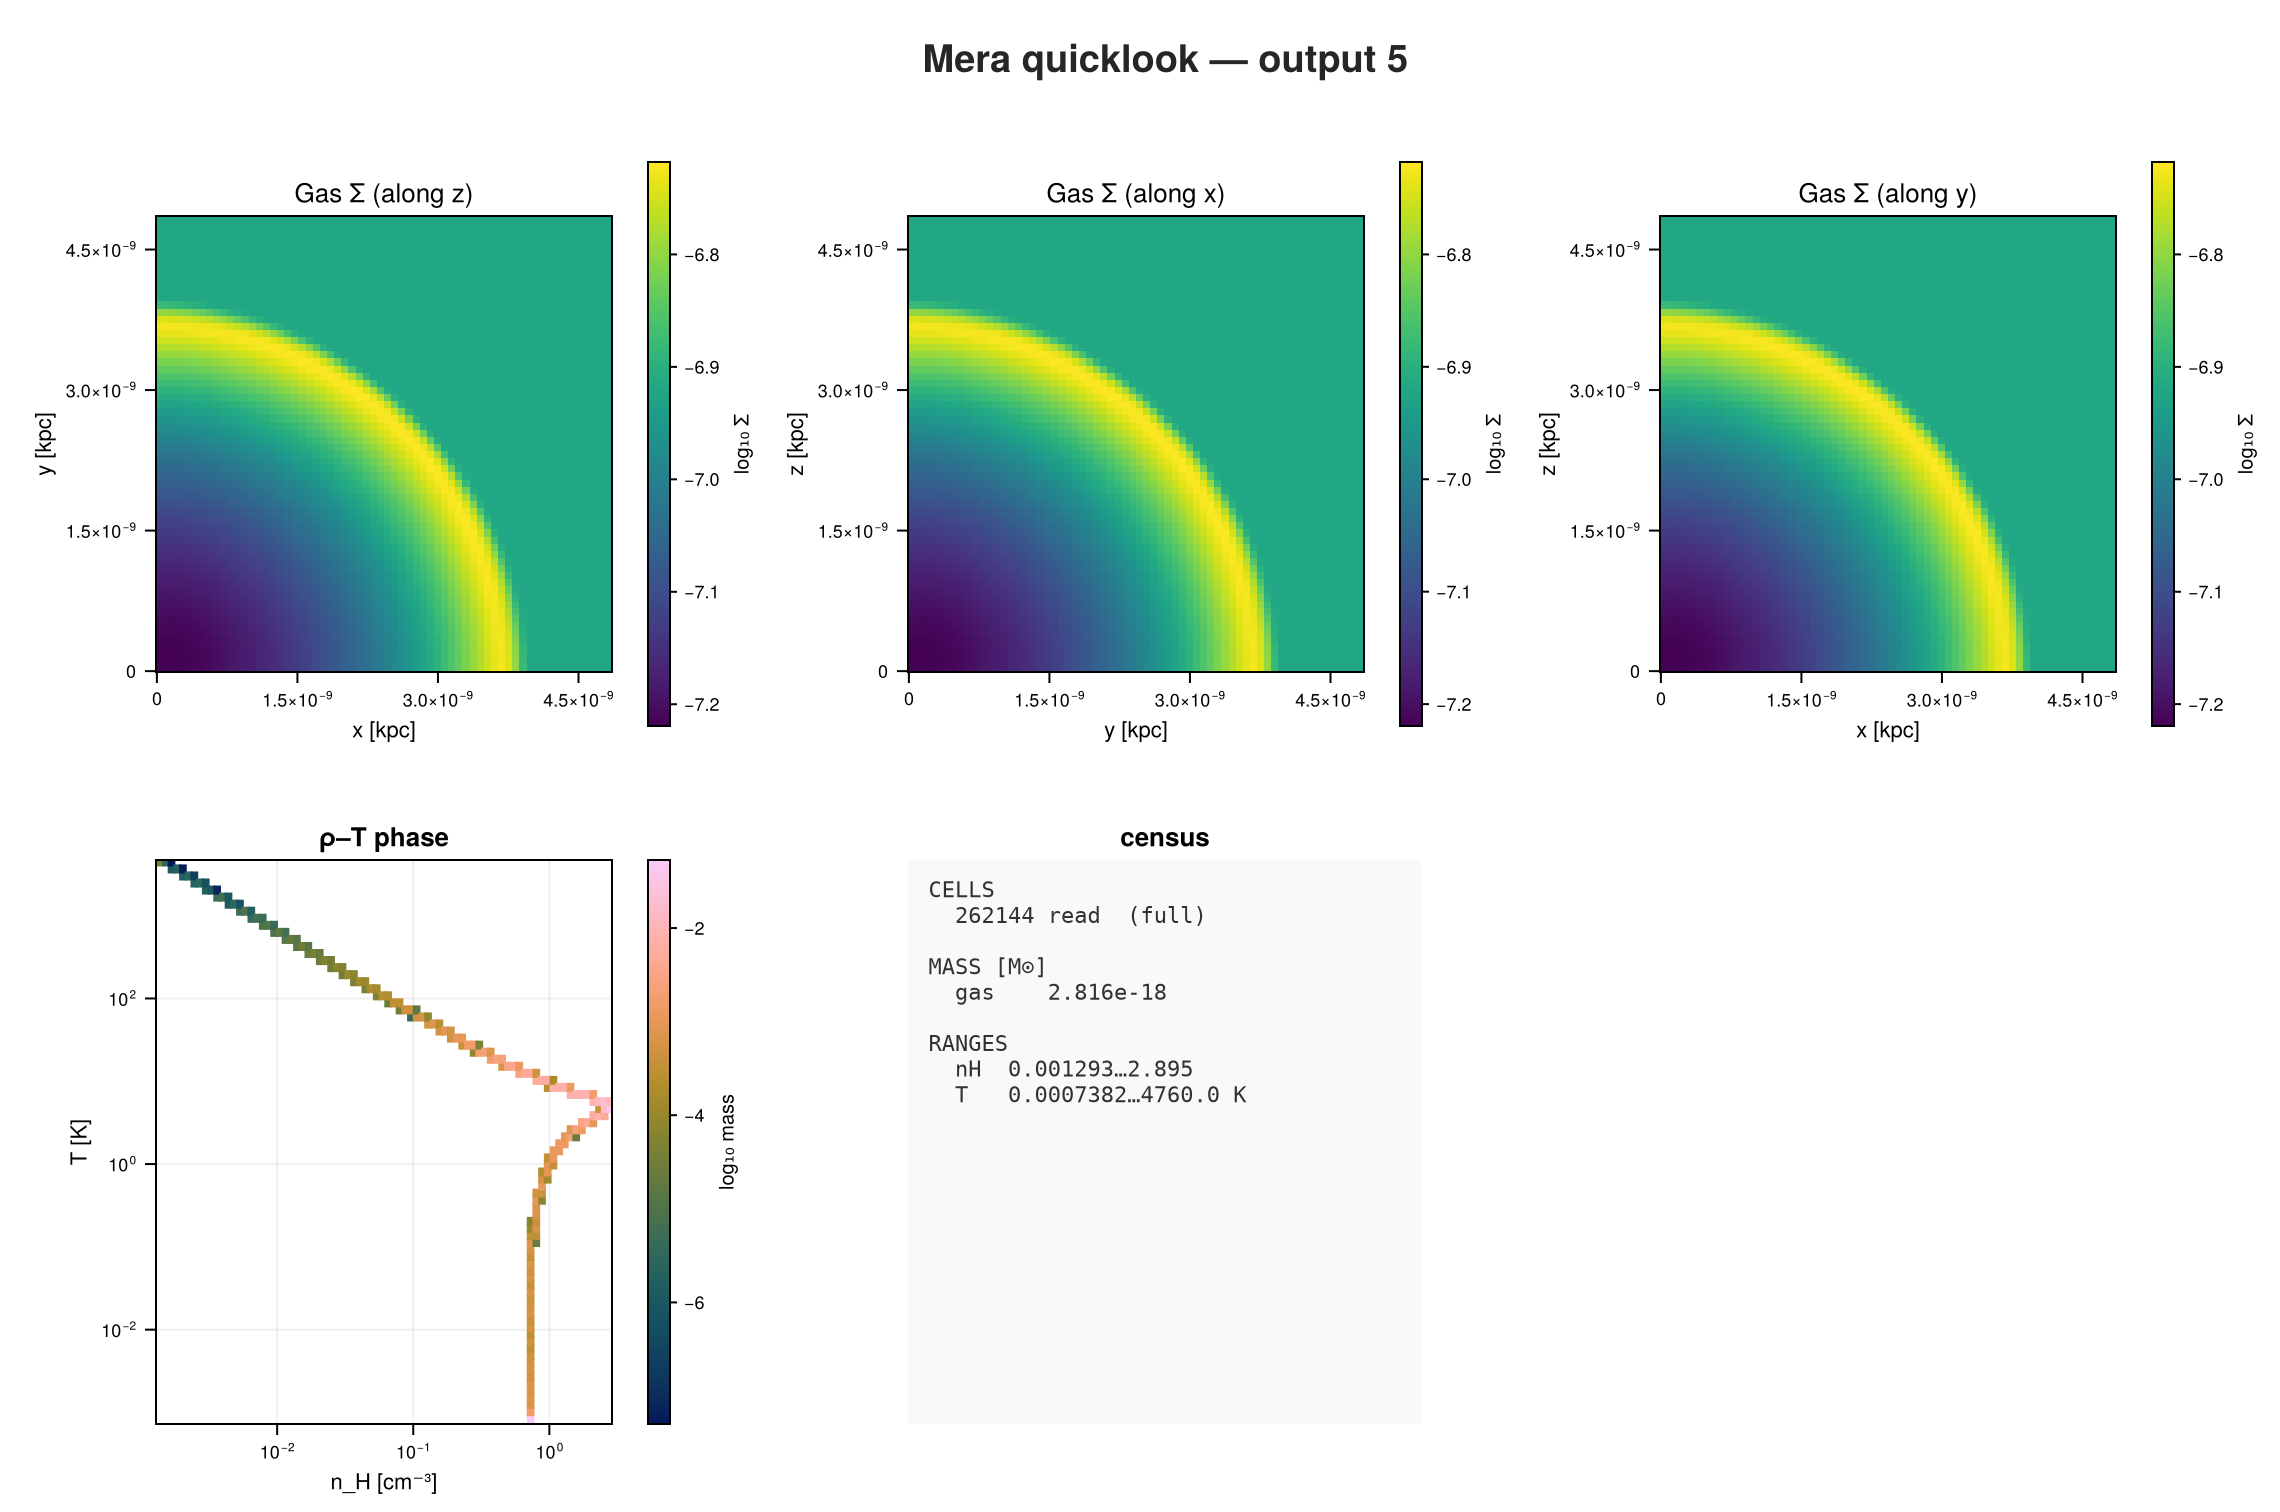

In [2]:
quicklookplot(ql)


Three column-density maps, one along each axis, and a density-temperature diagram.

The phase diagram is a thin curve rather than a cloud, and that is the run telling you what
physics it contains. This blast is adiabatic: no cooling, no heating, no chemistry. Every cell
started from the same uniform gas, so its temperature is fixed by the shock strength it met, and
density and temperature end up almost one-to-one. A simulation with cooling and heating pulling
against each other fills the plane instead.


The header names the code it found: `output 5 (PLUTO)`. You never told it the format.

**Why the three constants.** PLUTO writes its unit constants into the run's compiled
`definitions.h`, not into the output, so Mera cannot read them. Without them it treats one
code unit as one CGS unit and every physical number is meaningless. This run's `run.log`
records them, so we pass them in and the box, the masses and the densities are real.


## 2. The details: `getinfo`

`getinfo` reads the small metadata files, not the data. It is fast, and it is how you decide
what to load.


In [3]:
info = getinfo(5, path; unit_length=UL, unit_density=UD, unit_velocity=UV);
setcomposition!(info; X_frac=0.711, mu=0.614);


[Mera]: 2026-09-15T19:34:00.395

Code: PLUTO
output: 5  time: 0.5 [code units]
grid: 64³ uniform Cartesian, level 6, boxlen = 1.0
variables: (rho, vx, vy, vz, p)
-------------------------------------------------------
[Mera]: composition not recorded by this format; using X = 0.76, mu = 1.32 (RAMSES convention) for :nH and :T. Change with setcomposition!(info; X_frac=…, mu=…).


Everything you need first: which code wrote it, the snapshot time, the grid, and the
variables the file contains. The answer is kept in `info.simcode`.


In [4]:
info.simcode, info.levelmin, info.levelmax, info.boxlen, info.variable_list


("PLUTO", 6, 6, 1.0, [:rho, :vx, :vy, :vz, :p])

This run is a **uniform grid**: `levelmin == levelmax`, so there is one resolution
everywhere. An AMR snapshot shows a range here instead.


## 3. What else could be loaded?

A snapshot does not always hold every kind of data. Ask, rather than guess.


In [5]:
capabilities(info)                  # what this code can provide


3-element Vector{Symbol}:
 :info
 :hydro
 :particles

In [6]:
supports(info, :gravity)            # ... and what it cannot


false

PLUTO can carry particles as well as gas, so both are listed. This particular run is gas
only, so the rest of the page uses `gethydro`. Asking for something a code does not support
fails with a message naming what it does have, instead of returning something wrong.


## 4. Load the gas

The same call you would use on a RAMSES snapshot.


In [7]:
gas = gethydro(info);


[Mera]: PLUTO hydro 262144 cells (of 262144), vars rho, vx, vy, vz, p


## 5. What the data looks like

Mera keeps the cells as one table, one row per cell.


In [8]:
gas.data


Table with 262144 rows, 8 columns:
cx  cy  cz  rho         vx          vy          vz         p
───────────────────────────────────────────────────────────────────
1   1   1   0.00194566  0.00435383  0.00443672  0.0045208  0.116222
1   1   2   0.00194477  0.00436522  0.0044479   0.013515   0.116223
1   1   3   0.00194189  0.00441037  0.0044923   0.0223949  0.116224
1   1   4   0.00193689  0.00451584  0.00459599  0.0309676  0.116226
1   1   5   0.00192981  0.00470266  0.00477949  0.0389575  0.116228
1   1   6   0.00192079  0.00497677  0.00504826  0.046035   0.11623
1   1   7   0.00191002  0.00532228  0.0053862   0.0518926  0.116233
1   1   8   0.00189779  0.0057012   0.00575575  0.0563256  0.116236
1   1   9   0.00188451  0.00606422  0.00610846  0.0593297  0.11624
1   1   10  0.00187065  0.00636865  0.00640264  0.0609904  0.116243
1   1   11  0.0018568   0.00659378  0.00661835  0.0617348  0.116248
1   1   12  0.00184345  0.00674445  0.00676144  0.0616345  0.116248
⋮
64  64  54  1.0     

The first columns are the cell's address on the grid, `cx`, `cy`, `cz`, counted from 1.
The rest are the variables the file stored. A cell's position is worked out from its address
rather than stored, which is what keeps an AMR table small.

There is no `level` column here because the grid is uniform, so the level is the same for
every cell and there is nothing to store.

Ask for any of it by name:


In [9]:
getvar(gas, :rho) |> extrema        # code units


(0.0018039137622911177, 4.040484204505616)

In [10]:
getvar(gas, :cellsize)[1]           # how big one cell is


0.015625

## 6. Quantities the file does not contain

Temperature is not stored in this snapshot. Mera derives it from pressure and density, and the
same holds for sound speed, angular momentum and many more. `list_fields(:hydro)` lists them.

Temperature needs one number no simulation format records: the gas composition. Mera starts from
the RAMSES convention, a hydrogen mass fraction of 0.76 with μ = 1/X = 1.32. PLUTO without a
chemistry module treats the gas as **fully ionised** instead, so say so:


In [11]:
extrema(getvar(gas, :T, :K))        # Kelvin, using the composition set above


(0.0007382325268768512, 4759.801990838847)

That is about half what the default assumption would have given, which is the size of the error
you inherit by not saying anything.

If you would rather not commit to a composition, ask for `:K_mu`, which is Kelvin **per unit μ**,
and multiply by whatever your run implies:


In [12]:
extrema(getvar(gas, :T, :K_mu))


(0.001202333105662624, 7752.120506252194)

In [13]:
msum(gas)                           # total gas mass


1.0

## 7. A projection

Column density along z. Nothing here is PLUTO-specific: this is the same `projection` call
used throughout the RAMSES tutorials.


In [14]:
proj = projection(gas, :sd, direction=:z);
size(proj.maps[:sd])


[Mera]: 2026-09-15T19:34:02.248



domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [cm] :: 1.496e13 [cm]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [cm] :: 1.496e13 [cm]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [cm] :: 1.496e13 [cm]

Selected var(s)=(:sd,) 
Weighting      = :mass

Effective resolution: 64^2
Map size: 64 x 64
Pixel size: 2.3375e11 [cm]
Simulation min.: 2.3375e11 [cm]

Available threads: 8
Requested max_threads: 8
Variables: 1 (sd)
Processing mode: Sequential (single thread)


(64, 64)

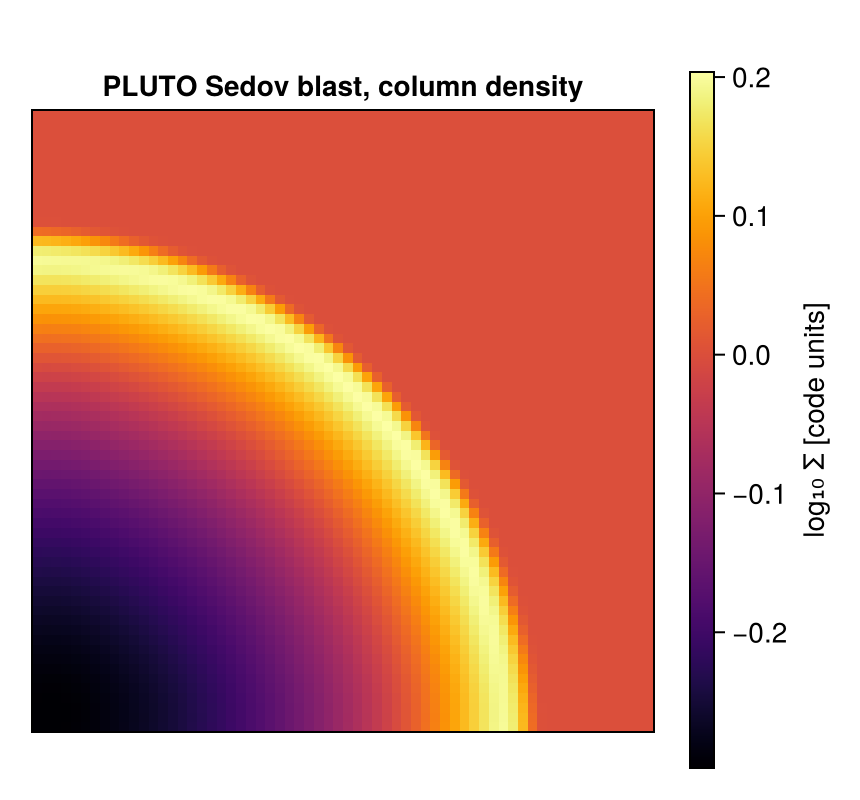

In [15]:
fig = Figure(size=(430, 400))
ax  = Axis(fig[1,1]; title="PLUTO Sedov blast, column density", aspect=DataAspect())
hidedecorations!(ax)
hm = heatmap!(ax, log10.(proj.maps[:sd]'); colormap=:inferno)
Colorbar(fig[1,2], hm, label="log₁₀ Σ [code units]")
fig


## Where to go next

That is the whole first look: `quicklook` for a census, `getinfo` to see what is there,
`gethydro` to load it, `getvar` for anything derived, `projection` for a map.

From here **every tutorial on this site applies unchanged**, because the analysis works on
the table, not on the simulation code that wrote it. Sub-regions, profiles, phase diagrams,
movies and off-axis projections all behave the same way.

- PLUTO reader: what this format stores and what it does not
- Other Simulation Codes: the same for every other code Mera reads
